Il progetto consiste nello sviluppo di un modello di Machine Learning per il riconoscimento delle attività umane (Human Activity Recognition) basato sui dati dei sensori di uno smartphone(accelerometro e giroscopio) sia nel dominio del tempo che della frequenza. Partendo da un dataset di misurazioni fisiche ad alta dimensionalità, l'obiettivo è classificare sei diverse azioni quotidiane utilizzando la Principal Component Analysis (PCA) per ridurre la complessità e una Support Vector Machine (SVM) per la predizione, dimostrando così l'applicazione pratica di metodi matematici e statistici su un problema reale.
Le attività riconosciute sono le seguenti:

1. WALKING
2. WALKING_UPSTAIRS
3. WALKING_DOWNSTAIRS
4. SITTING
5. STANDING
6. LAYING



Carica le librerie necessarie.

In [29]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter,defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import KFold,GroupKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
import time

Scarica il dataset se non è già disponibile.

In [16]:
if not os.path.exists('UCI HAR Dataset'):
    # Scarica lo .zip dal repository ufficiale
    print("Scaricamento del dataset in corso...")
    !wget -q "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
    # Decomprime il file
    !unzip -q "UCI HAR Dataset.zip"
    print("Operazione completata!")
else:
    print("Dataset già presente in questo ambiente.")

Dataset già presente in questo ambiente.


Carica i nomi delle features e delle labels,corregge i nomi duplicati (in alcune mancano gli assi di riferimento) e inoltre carica il train e test set (70-30) già forniti dal dataset.

In [25]:
base_path= 'UCI HAR Dataset/'

# Carica i nomi delle features
features= pd.read_csv(f'{base_path}features.txt', sep=r'\s+', header=None, names=['index', 'feature_name'])
feature_names= features['feature_name'].tolist()

activity_labels = pd.read_csv(
    f'{base_path}activity_labels.txt', sep=r'\s+', header=None,
    names=['id', 'activity']
)
# dizionario {1: 'WALKING', 2: 'WALKING_UPSTAIRS', ...}
label_map = dict(zip(activity_labels['id'], activity_labels['activity']))

# lista ordinata per id crescente, da passare a target_names
target_names = [label_map[i] for i in sorted(label_map)]

# Conta tutte le feature per sapere in anticipo quali hanno duplicati
conteggi= Counter(feature_names)
clean_feature_names= []
visti= {}
assi= ['X', 'Y', 'Z']

for nome in feature_names:
    if conteggi[nome] > 1:
        # Se la colonna ha duplicati, inizializziamo il contatore e prendiamo la lettera
        visti[nome]= visti.get(nome, 0)
        clean_feature_names.append(f"{nome}-{assi[visti[nome]]}")
        visti[nome]+= 1
    else:
        clean_feature_names.append(nome)

# Visualizza i nomi di tutte le features
#pd.DataFrame({'Features': clean_feature_names})

# Check per valori nulli
#print(X_train.isna().values.any())

# Carica i file di addestramento e di validazione
X_train= pd.read_csv(f'{base_path}train/X_train.txt', sep=r'\s+', header=None, names=clean_feature_names)
y_train= pd.read_csv(f'{base_path}train/y_train.txt', sep=r'\s+', header=None, names=['Activity_Label'])
subject_train= pd.read_csv(f'{base_path}train/subject_train.txt', sep=r'\s+', header=None, names=['Subject_ID'])

X_test= pd.read_csv(f'{base_path}test/X_test.txt', sep=r'\s+', header=None, names=clean_feature_names)
y_test= pd.read_csv(f'{base_path}test/y_test.txt', sep=r'\s+', header=None, names=['Activity_Label'])
subject_test= pd.read_csv(f'{base_path}test/subject_test.txt', sep=r'\s+', header=None, names=['Subject_ID'])

X_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


Si effettua una analisi esplorativa sui dati tramite uno scree plot.

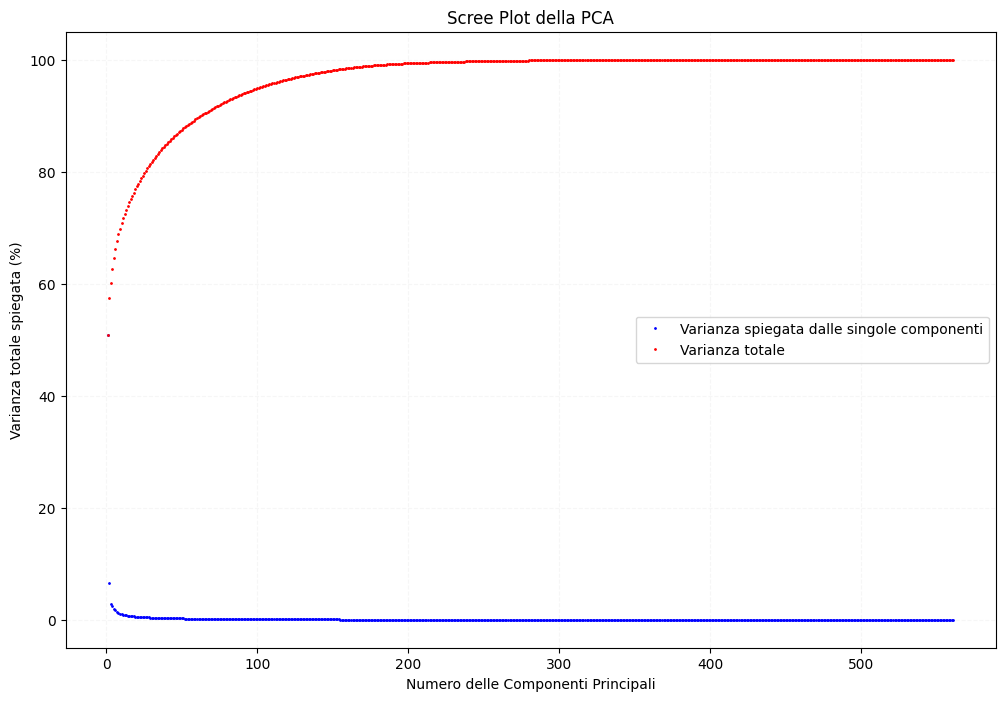

In [18]:
#Inizializza lo scaler e normalizza i dati
scaler= StandardScaler()
X_train_normalizzato= scaler.fit_transform(X_train)
X_test_normalizzato= scaler.transform(X_test)

# Inizializza la pca
pca=PCA()
pca.fit(X_train_normalizzato)

varianza_pc= pca.explained_variance_ratio_*100
varianza_totale=np.cumsum(varianza_pc)

#Plot
plt.figure(figsize=(12, 8))
plt.plot(range(1, len(varianza_pc) + 1), varianza_pc,
        linestyle="None",color='b',marker="o",label='Varianza spiegata dalle singole componenti',markersize=1)
plt.plot(range(1, len(varianza_pc) + 1), varianza_totale,
        linestyle="None",color='r',marker="o",label='Varianza totale',markersize=1)
plt.title('Scree Plot della PCA')
plt.xlabel('Numero delle Componenti Principali')
plt.ylabel('Varianza totale spiegata (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.1)
plt.show()


Si effettua una cross validazione tramite GroupKFold per scegliere il miglior modello di predizione con PCA.Per ogni fold:
1. normalizzazione
2. PCA(diversi parametri testati)
3. training e test(diversi parametri testati)

In [19]:
# ============================================================
# CV NESTED: scelta di C, kernel E soglia di varianza (n_componenti)
# Scaler e PCA vengono fittati SOLO su ogni fold di training -> niente leakage
# Fold come ciclo più esterno: scaler e PCA calcolati una volta sola per fold
# (rispettivamente per fold, e per fold+soglia), poi riusati su tutte le
# combinazioni di kernel/C
# ============================================================


# Griglia di iperparametri
C_values = [0.1, 1, 10]
kernel_values = ['linear', 'rbf']
varianza_soglie = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

n_splits = 5
gkf = GroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Split fissati per confronto equo tra tutte le combinazioni
splits = list(gkf.split(
    X_train, y_train.values.ravel(), groups=subject_train.values.ravel()
))

# Strutture dati: chiave -> lista di valori accumulati sui fold
fold_scores = defaultdict(list)          # chiave: (kernel, C, soglia) -> [score_fold1, score_fold2, ...]
n_componenti_per_soglia = defaultdict(list)  # chiave: soglia -> [n_comp_fold1, n_comp_fold2, ...]

t0_cv = time.time()

for train_idx, val_idx in splits:
    # Dati grezzi (non normalizzati) del fold corrente
    X_fold_train_raw = X_train.values[train_idx]
    X_fold_val_raw   = X_train.values[val_idx]
    y_fold_train = np.array(y_train).ravel()[train_idx]
    y_fold_val   = np.array(y_train).ravel()[val_idx]

    # Scaler fittato solo sul training fold
    scaler_fold = StandardScaler()
    X_fold_train_scaled = scaler_fold.fit_transform(X_fold_train_raw)
    X_fold_val_scaled   = scaler_fold.transform(X_fold_val_raw)

    for soglia in varianza_soglie:
        # PCA fittata solo sul training fold già normalizzato
        pca_fold = PCA(n_components=soglia, svd_solver='full', random_state=42)
        X_fold_train_pca = pca_fold.fit_transform(X_fold_train_scaled)
        X_fold_val_pca   = pca_fold.transform(X_fold_val_scaled)

        n_componenti_per_soglia[soglia].append(pca_fold.n_components_)

        for kernel in kernel_values:
            for C in C_values:
                model = SVC(C=C, kernel=kernel, gamma='scale')
                model.fit(X_fold_train_pca, y_fold_train)

                y_pred_val = model.predict(X_fold_val_pca)
                score = accuracy_score(y_fold_val, y_pred_val)

                fold_scores[(kernel, C, soglia)].append(score)

tempo_cv = time.time() - t0_cv

# ------------------------------------------------------------
# Aggregazione dei risultati: media, std, SE per ogni combinazione
# ------------------------------------------------------------
risultati_grid = []

for (kernel, C, soglia), scores in fold_scores.items():
    avg_score = np.mean(scores)
    std_score = np.std(scores, ddof=1)
    se_score = std_score / np.sqrt(n_splits)
    avg_n_componenti = np.mean(n_componenti_per_soglia[soglia])

    print(f"Kernel: {kernel:<8} | C: {C:<5} | Varianza: {soglia:.2f} "
          f"-> Accuracy Media: {avg_score:.4f} (+/- {se_score:.4f}) "
          f"| N.componenti medio: {avg_n_componenti:.1f}")

    risultati_grid.append({
        'kernel': kernel, 'C': C, 'varianza_soglia': soglia,
        'accuracy_media': avg_score, 'std_score': std_score, 'se_score': se_score,
        'n_componenti_medio': avg_n_componenti
    })

tempo_cv_totale = time.time() - t0_cv  # invariato, calcolato sopra come tempo_cv

risultati_grid_df = pd.DataFrame(risultati_grid).sort_values('accuracy_media', ascending=False)


# ------------------------------------------------------------
# Selezione "one-standard-error": tra le combinazioni con accuracy
# statisticamente indistinguibile dalla migliore, si sceglie quella
# più parsimoniosa (meno componenti, cioè soglia di varianza più bassa)
# ------------------------------------------------------------
riga_migliore = risultati_grid_df.iloc[0]
best_score = riga_migliore['accuracy_media']
se_best = riga_migliore['se_score']
soglia_one_se = best_score - se_best

# Candidate: tutte le combinazioni entro 1 SE dalla migliore
candidate_one_se = risultati_grid_df[risultati_grid_df['accuracy_media'] >= soglia_one_se]

# Tra le candidate, si sceglie quella con meno componenti medie
# (in caso di parità, si preferisce anche C più basso -> modello più semplice)
riga_scelta = candidate_one_se.sort_values(
    ['n_componenti_medio', 'C'], ascending=[True, True]
).iloc[0]

best_params = {
    'C': riga_scelta['C'],
    'kernel': riga_scelta['kernel'],
    'varianza_soglia': riga_scelta['varianza_soglia']
}

print(f"\nMigliore in assoluto (max accuracy): {riga_migliore[['kernel','C','varianza_soglia','accuracy_media']].to_dict()}")
print(f"Soglia one-SE (best_score - SE): {soglia_one_se:.4f}")
print(f"Modello scelto (one-SE, più parsimonioso): {best_params} "
      f"con Accuracy media: {riga_scelta['accuracy_media']:.4f}")
print(f"Tempo totale grid search CV (con PCA annidata): {tempo_cv:.2f} s")

risultati_grid_df




Kernel: linear   | C: 0.1   | Varianza: 0.70 -> Accuracy Media: 0.8372 (+/- 0.0225) | N.componenti medio: 9.2
Kernel: linear   | C: 1     | Varianza: 0.70 -> Accuracy Media: 0.8364 (+/- 0.0227) | N.componenti medio: 9.2
Kernel: linear   | C: 10    | Varianza: 0.70 -> Accuracy Media: 0.8364 (+/- 0.0231) | N.componenti medio: 9.2
Kernel: rbf      | C: 0.1   | Varianza: 0.70 -> Accuracy Media: 0.8229 (+/- 0.0230) | N.componenti medio: 9.2
Kernel: rbf      | C: 1     | Varianza: 0.70 -> Accuracy Media: 0.8331 (+/- 0.0233) | N.componenti medio: 9.2
Kernel: rbf      | C: 10    | Varianza: 0.70 -> Accuracy Media: 0.8237 (+/- 0.0241) | N.componenti medio: 9.2
Kernel: linear   | C: 0.1   | Varianza: 0.75 -> Accuracy Media: 0.8633 (+/- 0.0235) | N.componenti medio: 16.0
Kernel: linear   | C: 1     | Varianza: 0.75 -> Accuracy Media: 0.8598 (+/- 0.0236) | N.componenti medio: 16.0
Kernel: linear   | C: 10    | Varianza: 0.75 -> Accuracy Media: 0.8588 (+/- 0.0238) | N.componenti medio: 16.0
Kernel:

,kernel,C,varianza_soglia,accuracy_media,std_score,se_score,n_componenti_medio
35,rbf,10.0,0.95,0.915222,0.038365,0.017157,100.4
32,linear,10.0,0.95,0.913014,0.040819,0.018255,100.4
31,linear,1.0,0.95,0.911867,0.041442,0.018533,100.4
30,linear,0.1,0.95,0.911451,0.041713,0.018654,100.4
34,rbf,1.0,0.95,0.910457,0.039713,0.017760,100.4
24,linear,0.1,0.90,0.902171,0.040377,0.018057,62.0
25,linear,1.0,0.90,0.900106,0.040873,0.018279,62.0
29,rbf,10.0,0.90,0.899583,0.042465,0.018991,62.0
26,linear,10.0,0.90,0.898844,0.041921,0.018748,62.0
23,rbf,10.0,0.85,0.896092,0.038809,0.017356,39.4



Numero di componenti selezionate sull'intero training set: 63
Tempo di training del modello finale (PCA + SVM): 3.4916 s
Tempo di predizione sul test set: 0.1530 s

--- Risultati sul Test Set ---


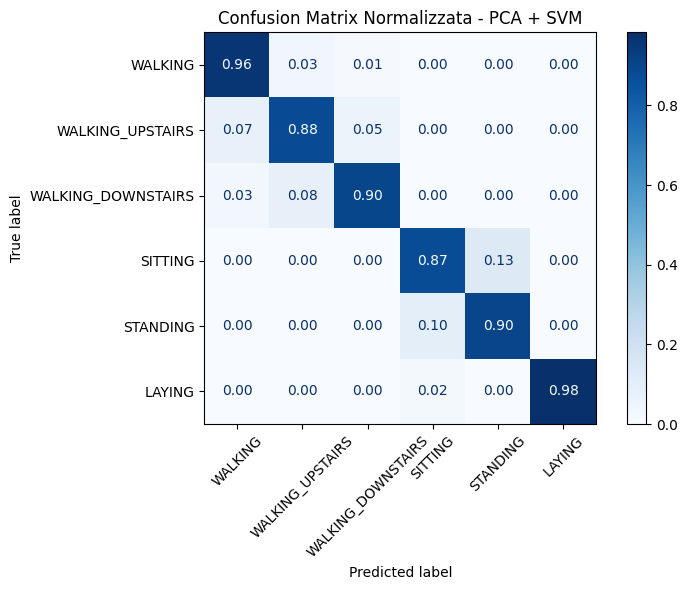


Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.91      0.96      0.94       496
  WALKING_UPSTAIRS       0.89      0.88      0.89       471
WALKING_DOWNSTAIRS       0.93      0.90      0.91       420
           SITTING       0.87      0.87      0.87       491
          STANDING       0.89      0.90      0.89       532
            LAYING       1.00      0.98      0.99       537

          accuracy                           0.92      2947
         macro avg       0.92      0.91      0.91      2947
      weighted avg       0.92      0.92      0.92      2947

Accuracy sul test set (PCA ottimizzata, one-SE): 0.9162


In [33]:
# ------------------------------------------------------------
# Fit finale: PCA (con la soglia scelta) su tutto il train, poi SVM
# ------------------------------------------------------------
t0_fit = time.time()

pca_finale = PCA(n_components=best_params['varianza_soglia'], svd_solver='full', random_state=42)
X_train_ridotto = pca_finale.fit_transform(X_train_normalizzato)
X_test_ridotto  = pca_finale.transform(X_test_normalizzato)
numero_componenti = pca_finale.n_components_

final_model = SVC(C=best_params['C'], kernel=best_params['kernel'], gamma='scale')
final_model.fit(X_train_ridotto, y_train.values.ravel())

tempo_fit = time.time() - t0_fit

t0_pred = time.time()
y_test_pred = final_model.predict(X_test_ridotto)
tempo_pred = time.time() - t0_pred

print(f"\nNumero di componenti selezionate sull'intero training set: {numero_componenti}")
print(f"Tempo di training del modello finale (PCA + SVM): {tempo_fit:.4f} s")
print(f"Tempo di predizione sul test set: {tempo_pred:.4f} s")

print("\n--- Risultati sul Test Set ---")

cm_pca_norm = confusion_matrix(y_test, y_test_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca_norm, display_labels=target_names)
disp.plot(ax=ax, cmap='Blues', values_format='.2f', xticks_rotation=45)
ax.set_title('Confusion Matrix Normalizzata - PCA + SVM')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred,target_names=target_names))

accuracy_pca = accuracy_score(y_test, y_test_pred)
print(f"Accuracy sul test set (PCA ottimizzata, one-SE): {accuracy_pca:.4f}")

Si effettua una cross validazione tramite GroupKFold per scegliere il miglior modello di predizione senza PCA,così da avere un confronto.Per ogni fold:
1. normalizzazione
2. training e test(diversi parametri testati)

In [21]:
# ============================================================
# BASELINE (SENZA PCA) - dataset intero (561 feature standardizzate)
# Da confrontare con la pipeline con PCA
# ============================================================

# Stessi iperparametri esplorati nella versione con PCA
C_values = [0.1, 1, 10]
kernel_values = ['linear', 'rbf']

n_splits = 5
gkf_baseline = GroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

best_score_baseline = 0
best_params_baseline = {}

t0_cv_baseline = time.time()

for kernel in kernel_values:
    for C in C_values:
        fold_scores = []

        for train_idx, val_idx in gkf_baseline.split(
            X_train, y_train.values.ravel(), groups=subject_train.values.ravel()):

            # Dati grezzi (non normalizzati) del fold corrente
            X_fold_train_raw = X_train.values[train_idx]
            X_fold_val_raw   = X_train.values[val_idx]
            y_fold_train = np.array(y_train).ravel()[train_idx]
            y_fold_val   = np.array(y_train).ravel()[val_idx]

            # Scaler fittato SOLO sul training fold -> niente leakage
            scaler_fold = StandardScaler()
            X_fold_train_scaled = scaler_fold.fit_transform(X_fold_train_raw)
            X_fold_val_scaled   = scaler_fold.transform(X_fold_val_raw)

            model = SVC(C=C, kernel=kernel, gamma='scale')
            model.fit(X_fold_train_scaled, y_fold_train)

            y_pred_val = model.predict(X_fold_val_scaled)
            score = accuracy_score(y_fold_val, y_pred_val)
            fold_scores.append(score)

        avg_score = np.mean(fold_scores)
        print(f"[Baseline] Kernel: {kernel:<8} | C: {C:<5} -> Accuracy Media: {avg_score:.4f}")

        if avg_score > best_score_baseline:
            best_score_baseline = avg_score
            best_params_baseline = {'C': C, 'kernel': kernel}

tempo_cv_baseline = time.time() - t0_cv_baseline

print(f"\nMigliori iperparametri (baseline): {best_params_baseline} con Accuracy: {best_score_baseline:.4f}")
print(f"Tempo totale grid search CV (baseline): {tempo_cv_baseline:.2f} s")

[Baseline] Kernel: linear   | C: 0.1   -> Accuracy Media: 0.9311
[Baseline] Kernel: linear   | C: 1     -> Accuracy Media: 0.9289
[Baseline] Kernel: linear   | C: 10    -> Accuracy Media: 0.9259
[Baseline] Kernel: rbf      | C: 0.1   -> Accuracy Media: 0.8847
[Baseline] Kernel: rbf      | C: 1     -> Accuracy Media: 0.9246
[Baseline] Kernel: rbf      | C: 10    -> Accuracy Media: 0.9282

Migliori iperparametri (baseline): {'C': 0.1, 'kernel': 'linear'} con Accuracy: 0.9311
Tempo totale grid search CV (baseline): 78.48 s



--- Risultati sul Test Set (Baseline - senza PCA) ---

Numero di feature utilizzate: 561
Tempo di training del modello finale: 0.9539 s
Tempo di predizione sul test set: 0.5396 s


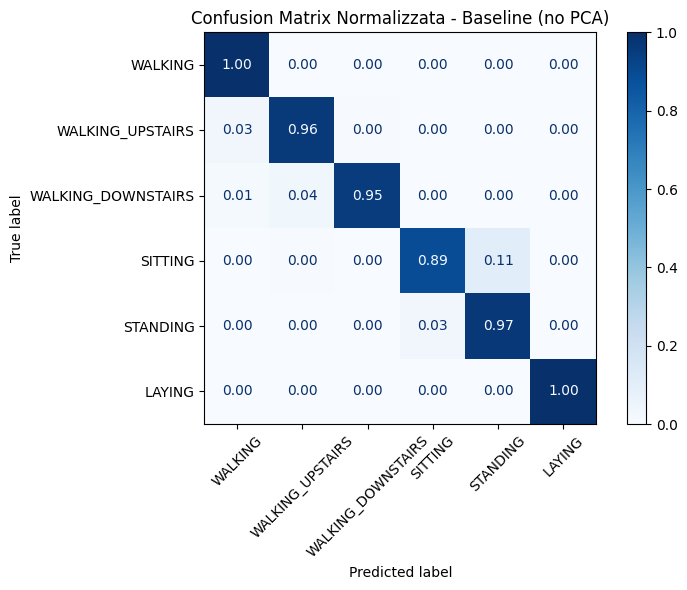


Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.96      1.00      0.98       496
  WALKING_UPSTAIRS       0.96      0.96      0.96       471
WALKING_DOWNSTAIRS       0.99      0.95      0.97       420
           SITTING       0.96      0.89      0.92       491
          STANDING       0.91      0.97      0.94       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947

Accuracy sul test set (baseline): 0.9617


In [32]:
# Modello finale sul dataset intero (senza riduzione dimensionale)
t0_fit_baseline = time.time()
final_model_baseline = SVC(C=best_params_baseline['C'], kernel=best_params_baseline['kernel'], gamma='scale')
final_model_baseline.fit(X_train_normalizzato, y_train.values.ravel())
tempo_fit_baseline = time.time() - t0_fit_baseline

t0_pred_baseline = time.time()
y_test_pred_baseline = final_model_baseline.predict(X_test_normalizzato)
tempo_pred_baseline = time.time() - t0_pred_baseline

print("\n--- Risultati sul Test Set (Baseline - senza PCA) ---")
print(f"\nNumero di feature utilizzate: {X_train_normalizzato.shape[1]}")
print(f"Tempo di training del modello finale: {tempo_fit_baseline:.4f} s")
print(f"Tempo di predizione sul test set: {tempo_pred_baseline:.4f} s")

cm_baseline_norm = confusion_matrix(y_test, y_test_pred_baseline, normalize='true')

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline_norm, display_labels=target_names)
disp.plot(ax=ax, cmap='Blues', values_format='.2f', xticks_rotation=45)
ax.set_title('Confusion Matrix Normalizzata - Baseline (no PCA)')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_baseline,target_names=target_names))

accuracy_baseline = accuracy_score(y_test, y_test_pred_baseline)
print(f"Accuracy sul test set (baseline): {accuracy_baseline:.4f}")

In [23]:
# Tabella riassuntiva di confronto
confronto = pd.DataFrame({
    'Pipeline': ['Baseline (no PCA)', 'PCA'],
    'N_features': [X_train_normalizzato.shape[1], numero_componenti],
    'Best_params': [best_params_baseline, best_params],
    'CV_accuracy': [best_score_baseline, riga_scelta['accuracy_media']],
    'Test_accuracy': [accuracy_baseline, accuracy_score(y_test, y_test_pred)],
    'Tempo_CV_grid_search_s': [tempo_cv_baseline,tempo_cv],
    'Tempo_training_finale_s': [tempo_fit_baseline, tempo_fit],
    'Tempo_predizione_s': [tempo_pred_baseline, tempo_pred]
})
confronto

,Pipeline,N_features,Best_params,CV_accuracy,Test_accuracy,Tempo_CV_grid_search_s,Tempo_training_finale_s,Tempo_predizione_s
0,Baseline (no PCA),561,"{'C': 0.1, 'kernel': 'linear'}",0.931078,0.961656,78.483355,0.988909,0.530254
1,PCA,63,"{'C': 0.1, 'kernel': 'linear', 'varianza_sogli...",0.902171,0.916186,240.203501,1.304262,0.140785
